# SLP
- Patrones Espaciales y Temporales de Presiones Superficiales en la Costa Oeste de Estados Unidos

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# system
import os
import os.path as op

# arrays
import numpy as np
import pandas as pd
import xarray as xr

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import datetime
# plotly
import plotly.express as px

# Principal component analysis
from sklearn.decomposition import PCA

#
import cartopy.crs as ccrs


## Cargar Dataset

In [3]:
# path
p_db = op.join(os.getcwd(),'..','..','data','SLP')
p_dat = op.join(p_db, 'mpr_West_US_mask.nc')

# load Sea level Pressure data (montlhy)
xds_SLP = xr.open_dataset(p_dat)

xds_SLP

<xarray.Dataset>
Dimensions:              (time: 456, lat: 16, lon: 20)
Coordinates:
  * time                 (time) datetime64[ns] 1979-01-31 ... 2016-12-31
  * lat                  (lat) float64 0.0 4.0 8.0 12.0 ... 48.0 52.0 56.0 60.0
  * lon                  (lon) float64 180.0 184.0 188.0 ... 248.0 252.0 256.0
Data variables:
    PRMSL_L101           (time, lat, lon) float32 ...
    PRMSL_L101_gradient  (time, lat, lon) float64 ...

# Visualización de Datos

## 1. Pintar Mapa de Presiones y gradientes del 31 de Enero de 1999

- Presiones: 'PRMSL_L101' y gradientes: 'PRMSL_L101_gradient'
- Pintar centro del Mapa en el Pacífico: projection=ccrs.PlateCarree(central_longitude = 180)
- Pintar colores de presion con la presion atmosferica en el centro (101400)

In [4]:
s1 = xds_SLP.sel(time = datetime.datetime(1999,1,31))

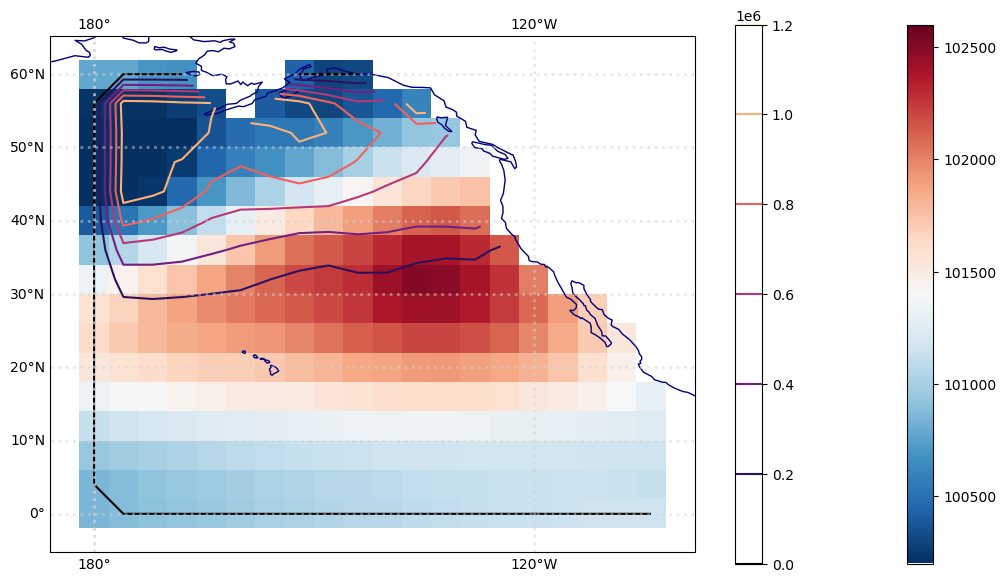

In [5]:
time = 190 #position of time to plot

plt.figure(figsize=(13, 7))    
ax = plt.subplot(111, projection=ccrs.PlateCarree(central_longitude = 180))

ax.coastlines(zorder=2, color = 'navy');
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)

im = ax.pcolormesh(s1.lon, s1.lat, s1.PRMSL_L101,  vmin = 101400-1200, vmax= 101400+1200, transform = ccrs.PlateCarree(), cmap = 'RdBu_r')
im1 = ax.contour(s1.lon, s1.lat, s1.PRMSL_L101_gradient,  5, transform = ccrs.PlateCarree(), cmap = 'magma')

plt.colorbar(im)
plt.colorbar(im1)

## 2. Pintar Mapa de Presiones y gradientes del 31 de Julio de 1999

- Presiones: 'PRMSL_L101' y gradientes: 'PRMSL_L101_gradient'
- Pintar centro del Mapa en el Pacífico: projection=ccrs.PlateCarree(central_longitude = 180)
- Pintar colores de presion con la presion atmosferica en el centro (101400)

In [6]:
s1 = xds_SLP.sel(time = datetime.datetime(1999,7,31))

In [7]:
s1

<xarray.Dataset>
Dimensions:              (lat: 16, lon: 20)
Coordinates:
    time                 datetime64[ns] 1999-07-31
  * lat                  (lat) float64 0.0 4.0 8.0 12.0 ... 48.0 52.0 56.0 60.0
  * lon                  (lon) float64 180.0 184.0 188.0 ... 248.0 252.0 256.0
Data variables:
    PRMSL_L101           (lat, lon) float32 ...
    PRMSL_L101_gradient  (lat, lon) float64 ...

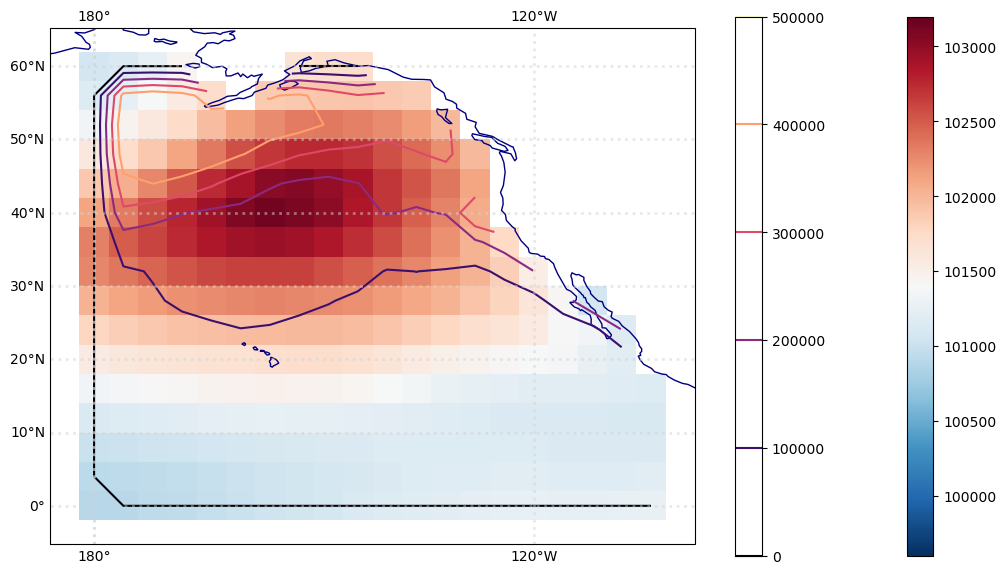

In [8]:
plt.figure(figsize=(13, 7))    
ax = plt.subplot(111, projection=ccrs.PlateCarree(central_longitude = 180))

ax.coastlines(zorder=2, color = 'navy');
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)

im = ax.pcolormesh(s1.lon, s1.lat, s1.PRMSL_L101,  vmin = 101400-1800, vmax= 101400+1800, transform = ccrs.PlateCarree(), cmap = 'RdBu_r')
im1 = ax.contour(s1.lon, s1.lat, s1.PRMSL_L101_gradient,  5, transform = ccrs.PlateCarree(), cmap = 'magma')

plt.colorbar(im)
plt.colorbar(im1)

## 3. Pintar Mapa de Presiones medias

- Presiones: 'PRMSL_L101' y gradientes: 'PRMSL_L101_gradient'
- Pintar centro del Mapa en el Pacífico: projection=ccrs.PlateCarree(central_longitude = 180)
- Pintar colores de presion con la presion atmosferica en el centro (101400)

In [9]:
s1 = xds_SLP.mean(dim = 'time')

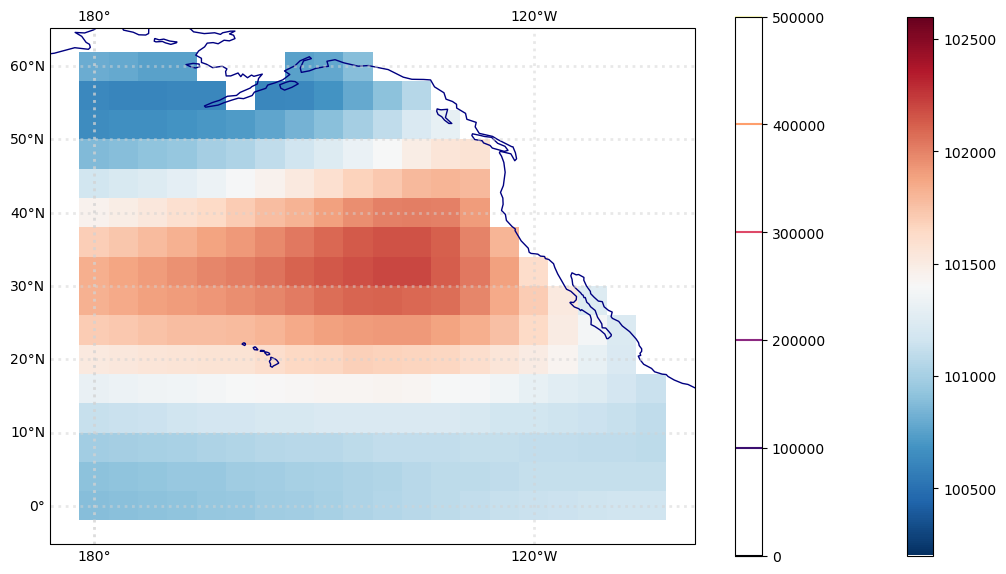

In [10]:

plt.figure(figsize=(13, 7))    
ax = plt.subplot(111, projection=ccrs.PlateCarree(central_longitude = 180))

ax.coastlines(zorder=2, color = 'navy');
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)

im = ax.pcolormesh(s1.lon, s1.lat, s1.PRMSL_L101,  vmin = 101400-1200, vmax= 101400+1200, transform = ccrs.PlateCarree(), cmap = 'RdBu_r')

plt.colorbar(im)
plt.colorbar(im1)

# Análisis de Componentes Principales de Presión

## 4. Generar y Estandarizar Matriz de Valores

- Para pasar de dimensiones time x lon x lat a time x position se puede usar:  <br>
**xds_SLP_stack = xds_SLP.stack(positions=("lon", "lat"))**

In [11]:
xds_SLP_stack = xds_SLP.stack(positions=("lon", "lat"))
matrix_pca = xds_SLP_stack.PRMSL_L101.values

In [12]:
# standarize predictor
pred_mean = np.mean(matrix_pca, axis=0)
pred_std = np.std(matrix_pca, axis=0)
matrix_pca_norm = (matrix_pca[:,:] - pred_mean) / pred_std
matrix_pca_norm[np.isnan(matrix_pca_norm)] = 0

## 5. Análisis de Componentes Principales

Hacer el análisis y generar el dataset xds_PCA
- El numero de componentes principales será el valor minimo entre el numero de tiempos y el numero de posiciones
- Al crear la matriz xds_PCA es necesario incluir el tiempo de los datos originales correctamente

In [13]:
n_components = np.min(matrix_pca.shape)
pca = PCA(n_components=n_components)

In [14]:
pca.fit(matrix_pca_norm)

PCA(n_components=320)

In [15]:
PCs = pca.transform(matrix_pca_norm)

In [16]:
xds_PCA = xr.Dataset(
    {
        'PCs': (('time', 'n_components'), PCs),
        'EOFs': (('points','n_components'), pca.components_.T),
        'variance': (('n_components',), pca.explained_variance_),
        'means': (('points',), pred_mean),
        'stds': (('points',), pred_std),
        'time': (('time'), xds_SLP.time.values)
    }
)

## 6. Pintar la varianza explicada acumulada y seleccionar las PCs que explican el 99%

Number of PCs explaining 99% of the variance = 18


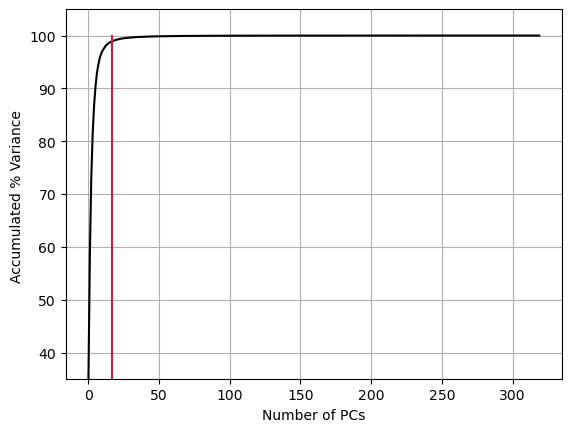

In [17]:
n_perc = 99

s= np.where(np.cumsum(pca.explained_variance_ratio_*100)>n_perc)[0]

n_pcs = s[0]

print('Number of PCs explaining {0}% of the variance = {1}'.format(n_perc, n_pcs))
plt.plot(np.cumsum(pca.explained_variance_ratio_*100), color = 'black')
plt.plot([s[0]-1, s[0]-1], [pca.explained_variance_ratio_[0]*100,100], color = 'crimson')

plt.xlabel('Number of PCs')
plt.ylabel('Accumulated % Variance ')
plt.ylim(pca.explained_variance_ratio_[0]*100, 105)
plt.grid()


## 7. Pintar las cinco primeras EOFs y sus correspondientes PCs

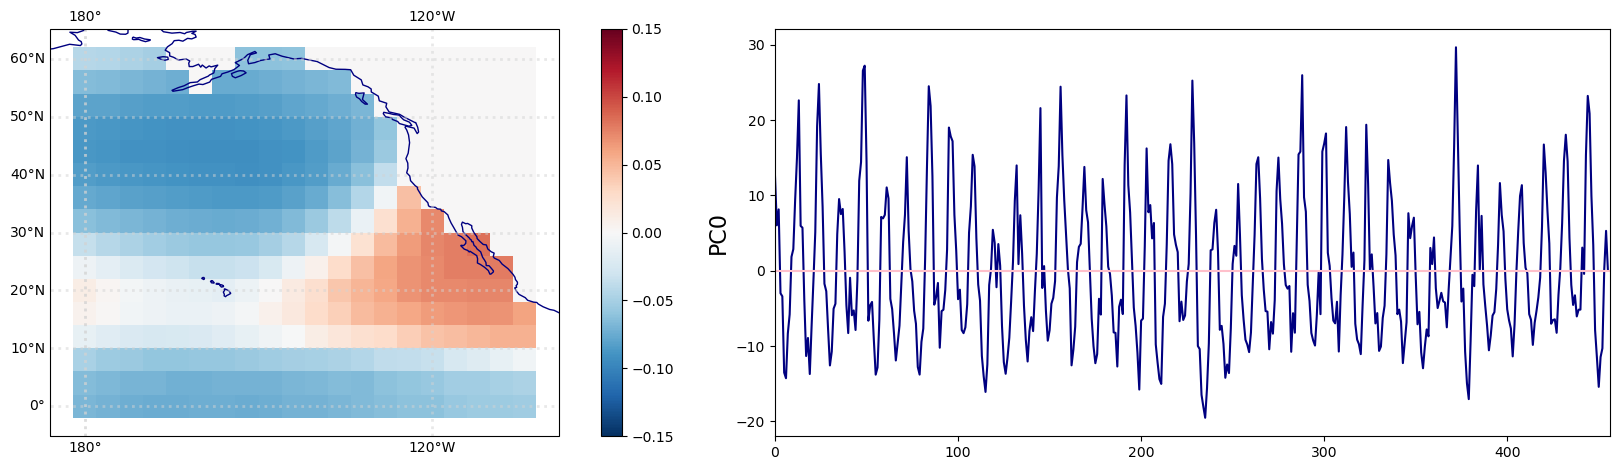

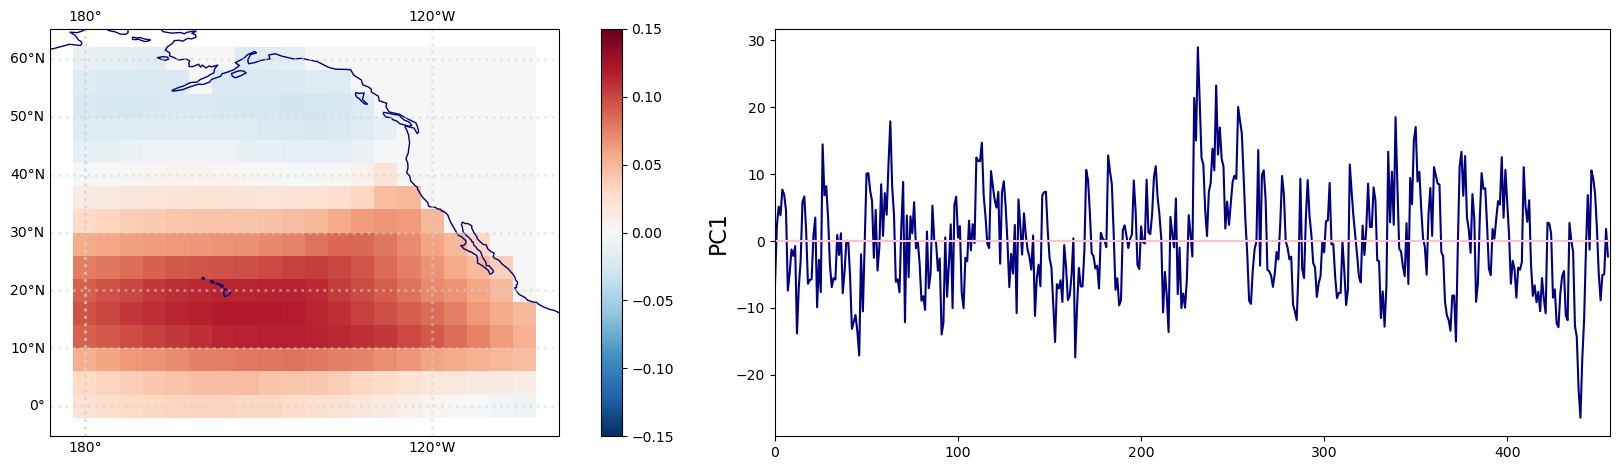

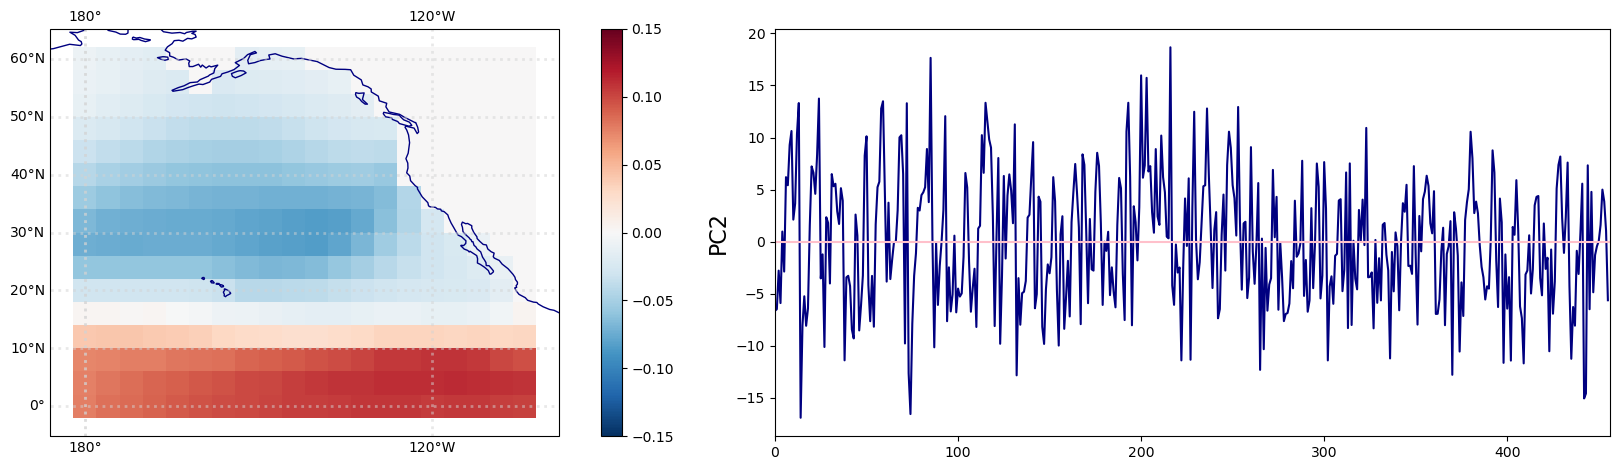

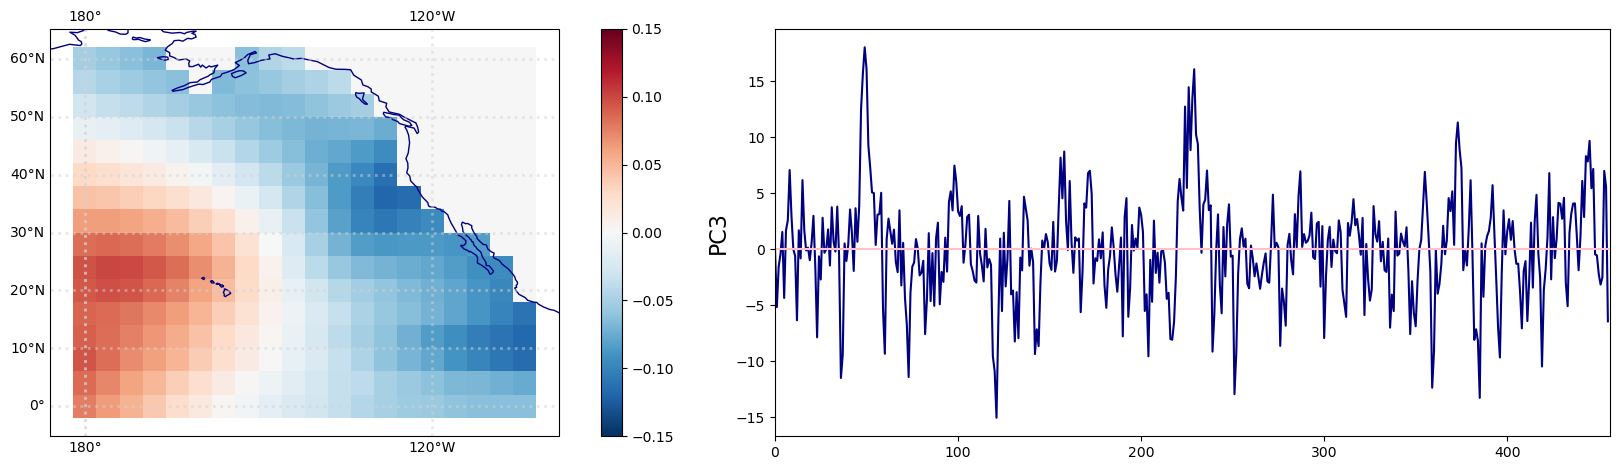

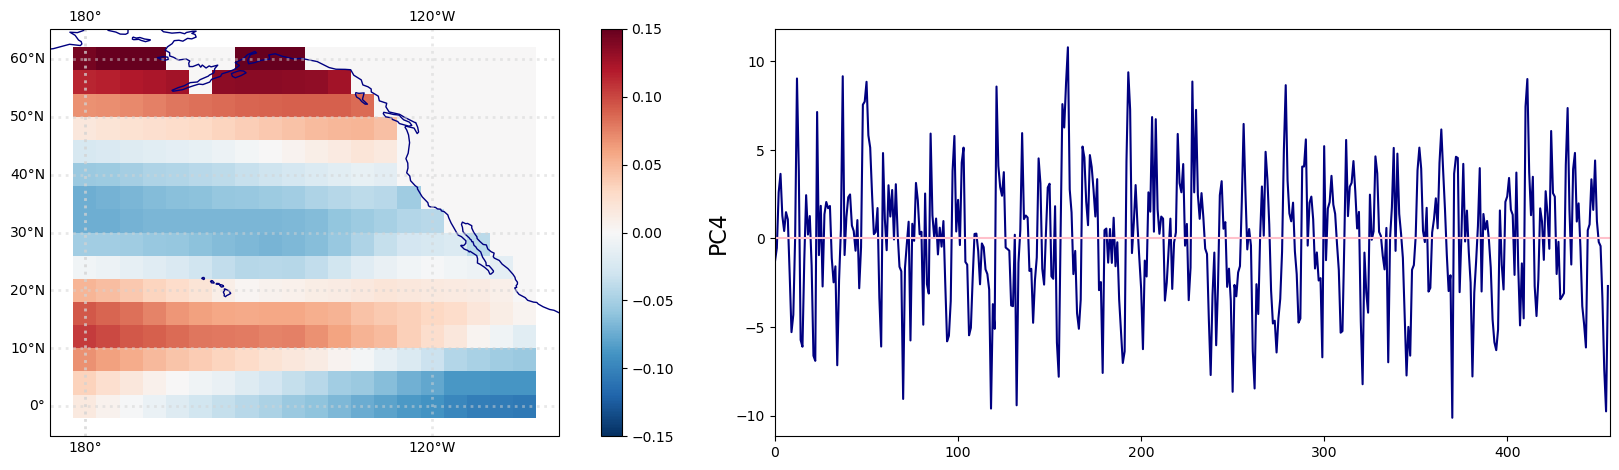

In [18]:
for pc_plot in range(5):
    
    
    var_plot = xds_PCA.isel(n_components = pc_plot).EOFs.values
    var_plot = np.reshape(var_plot, (len(xds_SLP.lon), len(xds_SLP.lat))).T
    
    fig = plt.figure(figsize = [20, 5], tight_layout=True)

    gs = gridspec.GridSpec(1, 2)
    ax = fig.add_subplot(gs[0,0], projection=ccrs.PlateCarree(central_longitude = 180))

    ax.coastlines(zorder=2, color = 'navy');
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)

    im = ax.pcolormesh(xds_SLP.lon.values, xds_SLP.lat.values,var_plot, transform = ccrs.PlateCarree(), vmin=-.15, vmax=.15, cmap = 'RdBu_r')
    plt.colorbar(im, ax=ax)


    ax1 = fig.add_subplot(gs[0,1])
    ax1.plot(xds_PCA.isel(n_components = pc_plot).PCs.values, color = 'navy')
    ax1.plot([0, len(xds_PCA.time)], [0,0], color = 'pink')
    ax1.set_xlim([0, len(xds_PCA.time)])
    ax1.set_ylabel('PC{0}'.format(pc_plot), fontsize = 16)


## 8. Reconstruir el Campo Espacial del 31 de Enero de 1999

- Utilizar las PCs que explican la varianza del 99%

- First we select the ones explaining the % of the variance defined above

In [19]:
xds_PCA = xds_PCA.isel(n_components = range(n_pcs))

- Then we can reconstruct the spatial field back from the PCs and the EOFs at each instant

$$X(x, t) = EOF_1 (x) * PC_1 (t) + EOF_2 (x) * PC_2 (t) + ... + EOF_n (x) * PC_n (t) $$

In [20]:
slp_reconstructed = (xds_PCA.PCs*(xds_PCA.EOFs)).sum(dim='n_components') * xds_PCA.stds + xds_PCA.means

- Select Time from Reconstruction and from real

In [21]:
time = datetime.datetime(1999,1,31)

slp_recon_time = slp_reconstructed.sel(time=time).values #Vector
slp_real_time = xds_SLP.sel(time = time).PRMSL_L101.values #Matrix

## 9. Pintar Campo de SLP real, reconstruido y sus diferencias

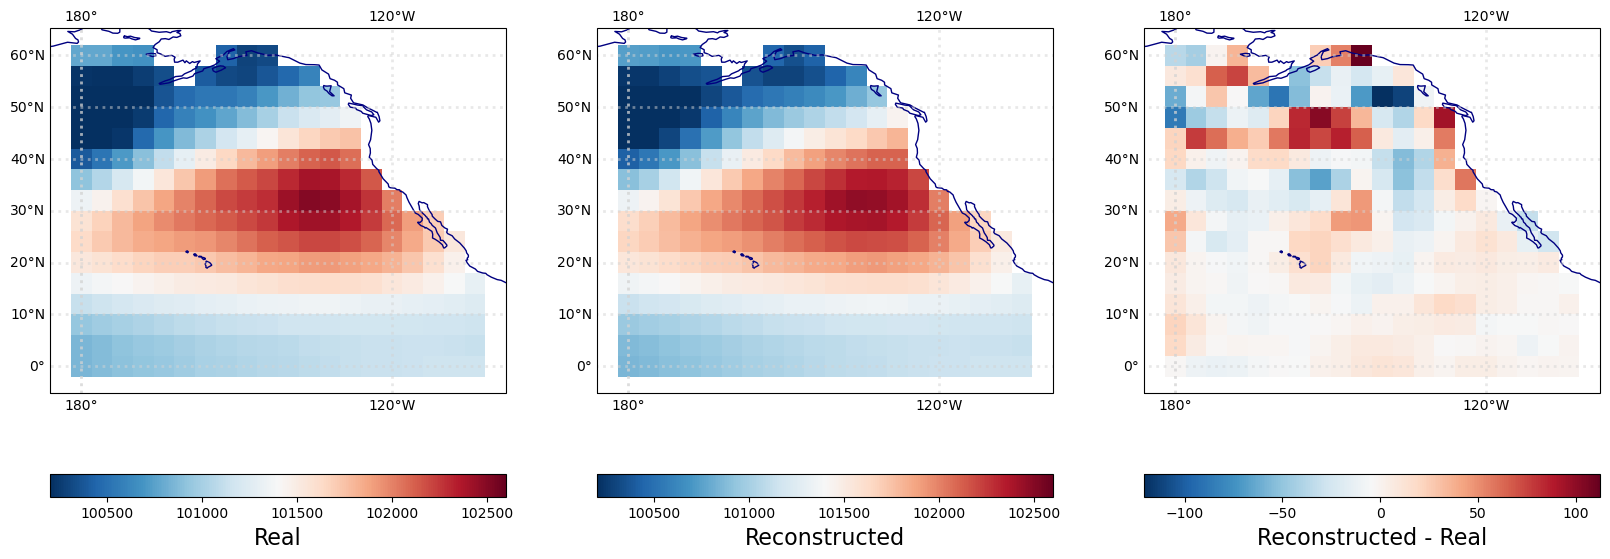

In [22]:
time = 190 #position of time to plot

plt.figure(figsize=(20, 7))    

#Real
var_plot = slp_real_time

ax = plt.subplot(131, projection=ccrs.PlateCarree(central_longitude = 180))
ax.coastlines(zorder=2, color = 'navy');
ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)
im = ax.pcolormesh(xds_SLP.lon.values, xds_SLP.lat.values, var_plot, transform = ccrs.PlateCarree(), 
                   vmin = 101400-1200, vmax= 101400+1200, cmap = 'RdBu_r')
plt.colorbar(im, orientation = 'horizontal').set_label('Real', fontsize= 16)

#Reconstruction
var_plot = np.reshape(slp_recon_time, (len(xds_SLP.lon), len(xds_SLP.lat))).T

ax1 = plt.subplot(132, projection=ccrs.PlateCarree(central_longitude = 180))
ax1.coastlines(zorder=2, color = 'navy');
ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)
im = ax1.pcolormesh(xds_SLP.lon.values, xds_SLP.lat.values, var_plot, transform = ccrs.PlateCarree(), 
                   vmin = 101400-1200, vmax= 101400+1200, cmap = 'RdBu_r')
plt.colorbar(im, orientation = 'horizontal').set_label('Reconstructed', fontsize= 16)


#Differences
var_plot = np.reshape(slp_recon_time, (len(xds_SLP.lon), len(xds_SLP.lat))).T
var_plot = var_plot - slp_real_time

ax1 = plt.subplot(133, projection=ccrs.PlateCarree(central_longitude = 180))
ax1.coastlines(zorder=2, color = 'navy');
ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='lightgrey', linestyle=':',  alpha=.5)
im = ax1.pcolormesh(xds_SLP.lon.values, xds_SLP.lat.values, var_plot, transform = ccrs.PlateCarree(), 
                    cmap = 'RdBu_r')
plt.colorbar(im, orientation = 'horizontal').set_label('Reconstructed - Real', fontsize= 16)